In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

In [2]:
#import dataset
df_train = pd.read_csv('exoTrain.csv')
df_train.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [3]:
df_train[df_train["LABEL"]==1]

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
37,1,-141.22,-81.79,-52.28,-32.45,-1.55,-35.61,-23.28,19.45,53.11,...,-50.79,-22.34,-36.23,27.44,13.52,38.66,-17.53,31.49,31.38,50.03
38,1,-35.62,-28.55,-27.29,-28.94,-15.13,-51.06,2.67,-5.21,9.67,...,-43.98,-38.22,-46.23,-54.40,-23.51,-26.96,-3.95,-0.34,10.52,-7.69
39,1,142.40,137.03,93.65,105.64,98.22,99.06,86.40,60.78,45.18,...,-0.99,-3.03,-30.27,-24.22,-35.10,-39.64,23.78,23.40,-0.50,0.97
40,1,-167.02,-137.65,-150.05,-136.85,-98.73,-103.14,-107.70,-123.19,-125.65,...,-97.43,-79.79,-80.62,-78.22,-105.06,-69.67,-90.45,-73.67,-66.71,-66.07
41,1,207.74,223.60,246.15,224.06,210.77,189.56,172.68,170.31,148.79,...,-53.06,-136.92,-174.97,-180.46,-164.01,-126.58,84.05,63.81,108.36,78.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5082,1,-91.91,-92.97,-78.76,-97.33,-68.00,-68.24,-75.48,-49.25,-30.92,...,139.95,147.26,156.95,155.64,156.36,151.75,-24.45,-17.00,3.23,19.28
5083,1,989.75,891.01,908.53,851.83,755.11,615.78,595.77,458.87,492.84,...,-26.50,-4.84,-76.30,-37.84,-153.83,-136.16,38.03,100.28,-45.64,35.58
5084,1,273.39,278.00,261.73,236.99,280.73,264.90,252.92,254.88,237.60,...,-26.82,-53.89,-48.71,30.99,15.96,-3.47,65.73,88.42,79.07,79.43
5085,1,3.82,2.09,-3.29,-2.88,1.66,-0.75,3.85,-0.03,3.28,...,10.86,-3.23,-5.10,-4.61,-9.82,-1.50,-4.65,-14.55,-6.41,-2.55


In [4]:
#replacing labels 2->1, 1->0
df_train.replace({"LABEL" : { 2:1, 1:0 }}, inplace=True)
df_train['LABEL'].unique()

array([1, 0], dtype=int64)

In [5]:
#droppng outliers
df_train.drop(df_train[df_train['FLUX.2']>0.25e6].index, axis=0, inplace=True)

In [6]:
#shape of training frame
df_train.shape

(5086, 3198)

In [7]:
#display the rows with null values
df_train[df_train.isnull().any(axis=1)]

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197


<AxesSubplot:>

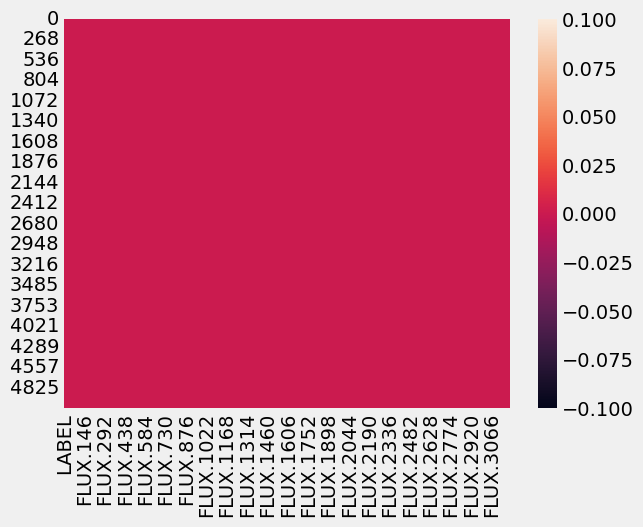

In [8]:
#diplay null values with heatmap
sns.heatmap(df_train.isnull())

In [9]:
#check number of labels in df
df_train['LABEL'].unique()

array([1, 0], dtype=int64)

In [10]:
#list all the indexes where LABEL is 2
list(df_train[df_train["LABEL"]==2].index)

[]

[Text(0, 0, '5049'), Text(0, 0, '37')]

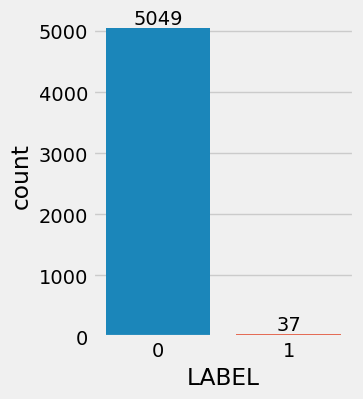

In [11]:
#vivusalizing the imbalanced data
plt.figure(figsize=(3,4))
ax= sns.countplot("LABEL", data=df_train)
ax.bar_label(ax.containers[0])

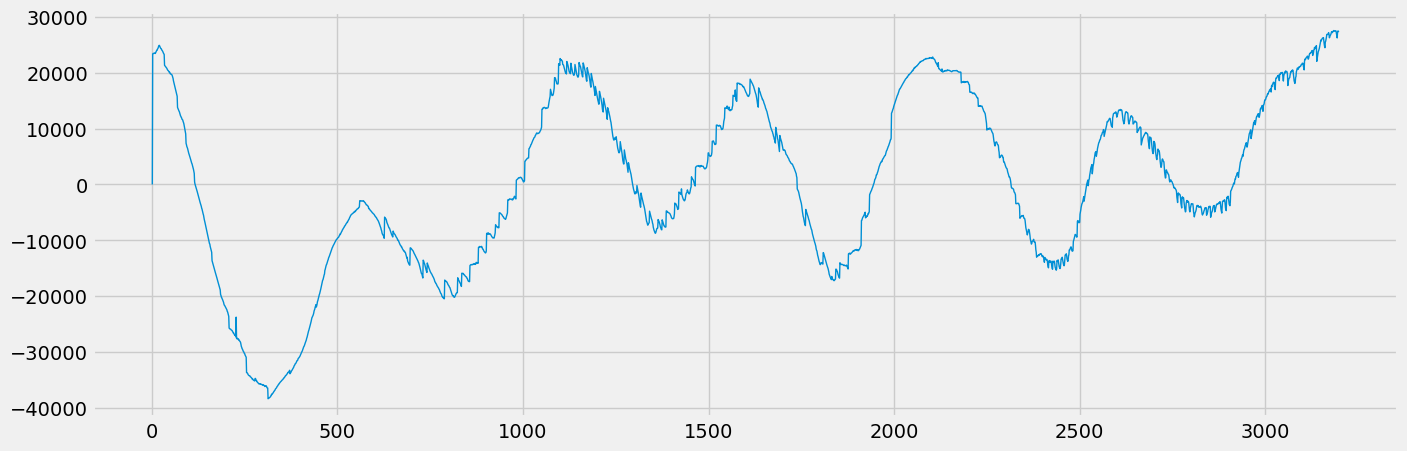

In [12]:
#plot random star from data
plt.figure(figsize=(15,5))
time = range(1,3199)
flux_value = df_train.iloc[412,:].values
plt.plot(time, flux_value, linewidth=1)
#result: found many outleirs.

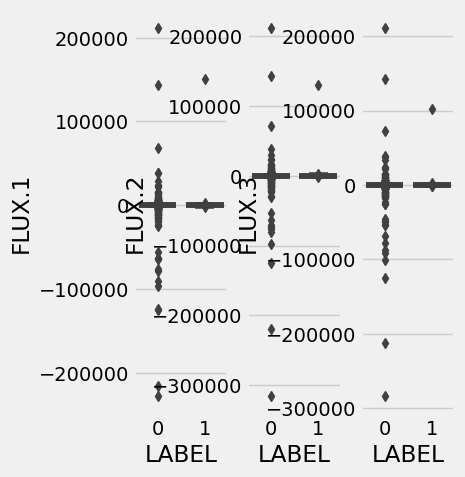

In [13]:
#confirming outliers using box plot, for some columns
plt.figure(figsize=(5,5))
for i in range(1,4):
    plt.subplot(1,4,i)
    sns.boxplot(data=df_train, x = 'LABEL', y="FLUX."+str(i))

In [14]:
#droppng outliers
df_train.drop(df_train[df_train['FLUX.2']>0.25e6].index, axis=0, inplace=True)

<AxesSubplot:xlabel='LABEL', ylabel='FLUX.846'>

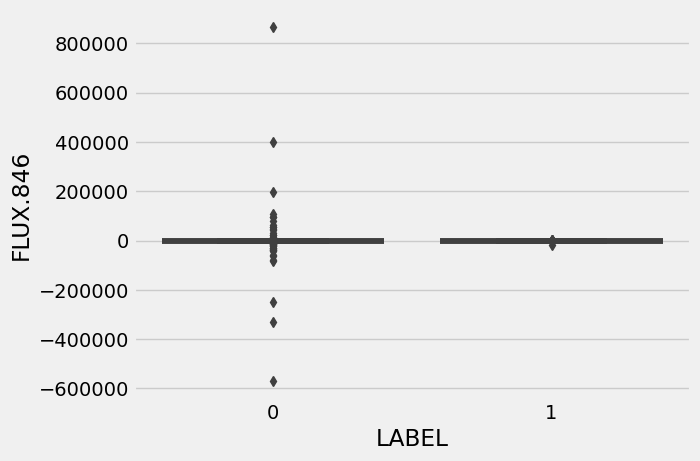

In [15]:
#checking for outleirs on boxplot
sns.boxplot(data=df_train, x= 'LABEL', y='FLUX.'+str(np.random.randint(1000)))

In [16]:
#extracting independent (x) and dependent (y) features from df_train
x  = df_train.drop(columns=['LABEL'])
y = df_train['LABEL']

In [21]:
#handling imbalanced data using randomOverSampler
from imblearn.over_sampling import RandomOverSampler

ros= RandomOverSampler()
x_train, y_train = ros.fit_resample(x_train,y_train)

In [22]:
x_train.shape

(7072, 3197)

In [23]:
#balanced data
y_ros.value_counts().plot(kind='bar')

NameError: name 'y_ros' is not defined

In [24]:
#checking and counting number of 0 and 1 values
from collections import Counter
print(f'Before ROS:-{Counter(y)}\n After ROS:- {Counter(y_ros)}')

NameError: name 'y_ros' is not defined

In [20]:
#splitting data for training and testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.3, random_state=0)

In [25]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [26]:
#import knn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score
#choosing k-value with min error
recall=[]
for i in range():
    knn_i = KNeighborsClassifier(n_neighbors=i)
    knn_i.fit(x_train, y_train)
    pred = knn_i.predict(x_test)
    recall.append(recall_score(y_test, pred))
recall

TypeError: range expected at least 1 argument, got 0

In [27]:
arg, val=recall.index(min(err_rate)), max(err_rate)
plt.figure(figsize=(3,3))
plt.plot(range(1,11), recall, 'co--', markersize=8)
plt.plot(arg+1, val, marker ='o', markersize=8, markerfacecolor='r', markeredgecolor='g')
plt.title('Recall wrt K values')
plt.xlabel('KValues')
plt.ylabel('Error Rate')
plt.plot()

NameError: name 'err_rate' is not defined

In [10]:
from sklearn.model_selection import GridSearchCV
pram = {
    "n_neighbors" : [3,5,7,9,12,13,15,17,21],
    "p" : [1,2,3],
    'algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute'],
    "weights" : ['uniform', 'distance']
}
grid_knn = GridSearchCV(knn, param_grid=pram)
grid_knn.fit(x_train,y_train)
grid_knn.best_params_

NameError: name 'knn' is not defined

In [24]:
#import knn
from sklearn.neighbors import KNeighborsClassifier

#choosing k=5
knn = KNeighborsClassifier(n_neighbors=250, metric='minkowski', p=2, weights='uniform', algorithm='kd_tree')
#fitting model
knn.fit(x_train,y_train)
#predict
y_pred = knn.predict(x_test)


In [25]:
#results
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
print('Validation accuracy of KNN -', accuracy_score(y_test, y_pred))
print()
print('Classification Report:- \n', classification_report(y_test, y_pred))
print()
print('Confusion matrix:- \n',confusion_matrix(y_test,y_pred))

Validation accuracy of KNN - 0.8931847968545217

Classification Report:- 
               precision    recall  f1-score   support

           0       1.00      0.90      0.94      1513
           1       0.04      0.54      0.08        13

    accuracy                           0.89      1526
   macro avg       0.52      0.72      0.51      1526
weighted avg       0.99      0.89      0.94      1526


Confusion matrix:- 
 [[1356  157]
 [   6    7]]


# checking the model on test set

In [14]:
#importing test
df_test = pd.read_csv('exoTest.csv')
df_test.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,119.88,100.21,86.46,48.68,46.12,39.39,18.57,6.98,6.63,...,14.52,19.29,14.44,-1.62,13.33,45.50,31.93,35.78,269.43,57.72
1,2,5736.59,5699.98,5717.16,5692.73,5663.83,5631.16,5626.39,5569.47,5550.44,...,-581.91,-984.09,-1230.89,-1600.45,-1824.53,-2061.17,-2265.98,-2366.19,-2294.86,-2034.72
2,2,844.48,817.49,770.07,675.01,605.52,499.45,440.77,362.95,207.27,...,17.82,-51.66,-48.29,-59.99,-82.10,-174.54,-95.23,-162.68,-36.79,30.63
3,2,-826.00,-827.31,-846.12,-836.03,-745.50,-784.69,-791.22,-746.50,-709.53,...,122.34,93.03,93.03,68.81,9.81,20.75,20.25,-120.81,-257.56,-215.41
4,2,-39.57,-15.88,-9.16,-6.37,-16.13,-24.05,-0.90,-45.20,-5.04,...,-37.87,-61.85,-27.15,-21.18,-33.76,-85.34,-81.46,-61.98,-69.34,-17.84


In [110]:
df_test.shape

(570, 3198)

In [15]:
#scaling dataset
X = df_test.drop(columns=['LABEL'])
Y=  df_test['LABEL']

In [16]:
Y.replace({2:1, 1:0})

0      1
1      1
2      1
3      1
4      1
      ..
565    0
566    0
567    0
568    0
569    0
Name: LABEL, Length: 570, dtype: int64

In [17]:
X = scaler.transform(X)

In [26]:
#prediction
Ypred = knn.predict(X)
knn.score(X,Y)

0.08596491228070176

In [27]:
#results
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
print('Validation accuracy of -', accuracy_score(Y, Ypred))
print()
print('Classification Report:- \n', classification_report(Y, Ypred))
print()
print('Confusion matrix:- \n',confusion_matrix(Y,Ypred))

Validation accuracy of - 0.08596491228070176

Classification Report:- 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.96      0.09      0.16       565
           2       0.00      0.00      0.00         5

    accuracy                           0.09       570
   macro avg       0.32      0.03      0.05       570
weighted avg       0.95      0.09      0.16       570


Confusion matrix:- 
 [[  0   0   0]
 [516  49   0]
 [  3   2   0]]


In [39]:
import optuna
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 1, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])
    leaf_size = trial.suggest_int('leaf_size', 10,100)
    p = trial.suggest_int('p', 1,2)
    
    knn = KNeighborsClassifier(
            n_neighbors = n_neighbors,
            weights     = weights,
            algorithm   = algorithm,
            leaf_size   = leaf_size,
            p           = p)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [40]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

[I 2024-11-05 11:31:10,646] A new study created in memory with name: no-name-81df9823-dfc1-4ff9-9206-f008c710bd96
[I 2024-11-05 11:31:25,301] Trial 0 finished with value: 0.9732673267326732 and parameters: {'n_neighbors': 34, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 73, 'p': 2}. Best is trial 0 with value: 0.9732673267326732.
[I 2024-11-05 11:31:34,783] Trial 1 finished with value: 0.968976897689769 and parameters: {'n_neighbors': 40, 'weights': 'distance', 'algorithm': 'auto', 'leaf_size': 79, 'p': 2}. Best is trial 0 with value: 0.9732673267326732.
[I 2024-11-05 11:33:44,688] Trial 2 finished with value: 0.9821782178217822 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 13, 'p': 1}. Best is trial 2 with value: 0.9821782178217822.
[I 2024-11-05 11:45:40,208] Trial 3 finished with value: 0.9927392739273927 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 73, 'p': 1}. Best is tri

In [41]:
print("Best hyperparameters: ", study.best_params) 
print("Best accuracy: ", study.best_value)

Best hyperparameters:  {'n_neighbors': 1, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 14, 'p': 2}
Best accuracy:  0.9986798679867986


In [42]:
knn_opt = KNeighborsClassifier(n_neighbors=1, weights='uniform', algorithm='brute', leaf_size=14, p=2)
knn_opt.fit(x_train, y_train)
y_opt_pred = knn.predict(x_test)
#results
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
print('Validation accuracy of KNN -', accuracy_score(y_test, y_opt_pred))
print()
print('Classification Report:- \n', classification_report(y_test, y_opt_pred))
print()
print('Confusion matrix:- \n',confusion_matrix(y_test,y_opt_pred))

Validation accuracy of KNN - 0.9924092409240924

Classification Report:- 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1512
           1       0.99      1.00      0.99      1518

    accuracy                           0.99      3030
   macro avg       0.99      0.99      0.99      3030
weighted avg       0.99      0.99      0.99      3030


Confusion matrix:- 
 [[1489   23]
 [   0 1518]]


In [45]:
#scaling dataset
X = df_test.drop(columns=['LABEL'])
Y=  df_test['LABEL']

# X = scaler.transform(X)

#prediction
Ypred = knn_opt.predict(X)
knn_opt.score(X,Y)

#results
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
print('Validation accuracy of KNN -', accuracy_score(Y, Ypred))
print()
print('Classification Report:- \n', classification_report(Y, Ypred))
print()
print('Confusion matrix:- \n',confusion_matrix(Y,Ypred))

Validation accuracy of KNN - 0.012280701754385965

Classification Report:- 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.88      0.01      0.02       565
           2       0.00      0.00      0.00         5

    accuracy                           0.01       570
   macro avg       0.29      0.00      0.01       570
weighted avg       0.87      0.01      0.02       570


Confusion matrix:- 
 [[  0   0   0]
 [558   7   0]
 [  4   1   0]]


In [46]:
#results
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
print('Validation accuracy of SVC -', accuracy_score(Y, Y_svc_pred))
print()
print('Classification Report:- \n', classification_report(Y, Y_svc_pred))
print()
print('Confusion matrix:- \n',confusion_matrix(Y,Y_svc_pred))

NameError: name 'Y_svc_pred' is not defined

In [75]:
Counter(y_test)

Counter({0: 1513, 1: 13})

In [6]:

#extracting independent (x) and dependent (y) features from df_train
x  = df_train.drop(columns=['LABEL'])
y = df_train['LABEL']


In [7]:

#splitting data for training and testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.3, random_state=0)

In [8]:
from imblearn.over_sampling import SMOTE
smote  =SMOTE()
x_train, y_train = smote.fit_resample(x_train,y_train)

In [9]:
from sklearn.preprocessing import StandardScaler
#scaling dataset
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [21]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression( penalty = 'l2', class_weight='balanced')
lr.fit(x_train, y_train)
y_pred_prob = lr.predict_proba(x_test)[:, 1]
model = 'LR'
lr

LogisticRegression(class_weight='balanced')

In [29]:
# Predict probabilities
y_pred_prob = lr.predict_proba(x_test)[:, 1]
# Apply custom threshold
threshold = 0.35
y_pred_custom = (y_pred_prob >= threshold).astype(int)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("Classification Report:\n", classification_report(y_test, y_pred_custom))


Accuracy: 0.9233289646133683
Confusion Matrix:
 [[1403  110]
 [   7    6]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96      1513
           1       0.05      0.46      0.09        13

    accuracy                           0.92      1526
   macro avg       0.52      0.69      0.53      1526
weighted avg       0.99      0.92      0.95      1526



In [10]:
from sklearn.svm import SVC
svc = SVC(kernel='sigmoid', probability=True)
svc.fit(x_train,y_train)
y_pred_prob = svc.predict_proba(x_test)[:,1]
model = 'SVC'

In [14]:
# Apply custom threshold
threshold = 0.50
y_pred_custom = (y_pred >= threshold).astype(int)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))
print("Classification Report:\n", classification_report(y_test, y_pred_custom))


Accuracy: 0.9056356487549148
Confusion Matrix:
 [[1380  133]
 [  11    2]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95      1513
           1       0.01      0.15      0.03        13

    accuracy                           0.91      1526
   macro avg       0.50      0.53      0.49      1526
weighted avg       0.98      0.91      0.94      1526



In [84]:
#results
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
print('Validation accuracy of',model, accuracy_score(y_test, y_pred))
print()
print('Classification Report:- \n', classification_report(y_test, y_pred))
print()
print('Confusion matrix:- \n',confusion_matrix(y_test,y_pred))

Validation accuracy of SVC 0.9790301441677588

Classification Report:- 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1513
           1       0.12      0.23      0.16        13

    accuracy                           0.98      1526
   macro avg       0.56      0.61      0.57      1526
weighted avg       0.99      0.98      0.98      1526


Confusion matrix:- 
 [[1491   22]
 [  10    3]]


In [85]:
#importing test
df_test = pd.read_csv('exoTest.csv')
df_test.head()
#scaling dataset
X = df_test.drop(columns=['LABEL'])
Y=  df_test['LABEL']
Y.replace({2:1, 1:0})
X = scaler.transform(X)


In [68]:
#prediction
Ypred = lr.predict(X)
# recall_score(Y,Ypred)
model = 'LR'

In [86]:
#prediction
Ypred = svc.predict(X)
svc.score(X,Y)
model = 'SVC'

In [87]:

#results
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
print('Validation accuracy of -',model, accuracy_score(Y, Ypred))
print()
print('Classification Report:- \n', classification_report(Y, Ypred))
print()
print('Confusion matrix:- \n',confusion_matrix(Y,Ypred))

Validation accuracy of - SVC 0.0035087719298245615

Classification Report:- 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.00      0.01       565
           2       0.00      0.00      0.00         5

    accuracy                           0.00       570
   macro avg       0.33      0.00      0.00       570
weighted avg       0.99      0.00      0.01       570


Confusion matrix:- 
 [[  0   0   0]
 [563   2   0]
 [  5   0   0]]


In [14]:
x_train.shape

(3560, 3197)

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
#initialize constructor
model = Sequential()

In [3]:
#add input layer
model.add(Dense(3197, activation = 'relu', input_shape=(3197,)))

C:\Users\shalima\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
#add hidden layer
model.add(Dense(100, activation='relu'))

In [5]:
#add output layer
model.add(Dense(1, activation='relu'))

In [6]:
#model output shape
model.output_shape

(None, 1)

In [7]:
#model SUmmary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 3197)                │      10,224,006 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │         319,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,543,907 (40.22 MB)

 Trainable params: 10,543,907 (40.22 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[-0.02129359, -0.00113231,  0.01438014, ..., -0.0027502 ,
         -0.01606383, -0.02484072],
        [-0.00209691, -0.02948279,  0.01275995, ..., -0.00214748,
         -0.02936764, -0.02115185],
        [ 0.01404383, -0.01744993, -0.00358132, ..., -0.01115824,
         -0.02393715, -0.00363749],
        ...,
        [ 0.02085913, -0.01591294, -0.02837523, ..., -0.00511988,
         -0.01466389, -0.01796984],
        [-0.00871545,  0.00216944, -0.02159997, ...,  0.00451101,
         -0.00199214, -0.01618585],
        [-0.0043885 ,  0.02077207, -0.01728489, ...,  0.0292436 ,
          0.02365768,  0.00063257]], dtype=float32),
 array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
 array([[-0.02141725, -0.01250717,  0.02931843, ...,  0.01423391,
         -0.03434915, -0.0083577 ],
        [ 0.00805215,  0.02160163, -0.0211142 , ..., -0.00886429,
         -0.02715496, -0.01559006],
        [ 0.01691716, -0.00396695, -0.03823879, ..., -0.04182076,
          0.00197478,  0.01478397]

In [29]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['recall'], )

In [30]:
model.fit(x_train, y_train, epochs=5, batch_size=1, verbose=1)

Epoch 1/5
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 350s 98ms/step - loss: 13.5795 - recall: 0.0106
Epoch 2/5
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 349s 98ms/step - loss: 103.8381 - recall: 0.0216
Epoch 3/5
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 346s 97ms/step - loss: 0.0428 - recall: 0.0056
Epoch 4/5
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 354s 99ms/step - loss: 1.0723 - recall: 0.0581
Epoch 5/5
3560/3560 ━━━━━━━━━━━━━━━━━━━━ 352s 99ms/step - loss: 0.5147 - recall: 0.1348


In [31]:
y_pred= model.predict(x_test)
y_pred = np.round(y_pred).flatten()
y_pred

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

In [32]:
#results
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
print('Validation accuracy of',model, accuracy_score(y_test, y_pred))
print()
print('Classification Report:- \n', classification_report(y_test, y_pred))
print()
print('Confusion matrix:- \n',confusion_matrix(y_test,y_pred))

Validation accuracy of <Sequential name=sequential, built=True> 0.991480996068152

Classification Report:- 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1513
           1       0.00      0.00      0.00        13

    accuracy                           0.99      1526
   macro avg       0.50      0.50      0.50      1526
weighted avg       0.98      0.99      0.99      1526


Confusion matrix:- 
 [[1513    0]
 [  13    0]]


# Exoplanet Hunter: Finding Planets Using Light Intensity

## Tutorial written by Ruhai Lin, Aled dela Cruz, and Karina Aguilar

In [46]:
# !pip install snntorch 
# !pip install torchvision 
!pip uninstall torchvision
!pip install torchvision --upgrade



^C
^C


In [32]:
#pytorch
import torch
import snntorch as snn
from snntorch import surrogate
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
# from torchvision import transforms

#SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

#plot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#metrics
from sklearn.metrics import confusion_matrix, roc_auc_score

In [49]:
class CustomDataset(Dataset):

    def __init__(self, csv_file, transform=None):
        with open(csv_file,"r") as f:
            self.data = pd.read_csv(f) # read the files
        self.labels = self.data.iloc[:,0].values - 1 # set the first line of the input data as the label (Originally 1 or 2, but we -1 here so they become 0 or 1)
        self.features = self.data.iloc[:, 1:].values # set the rest of the input data as the feature (FLUX over time)
        self.transform = transform # transformation (which is None) that will be applied to samples.

        # If you want to have a look at how does this dataset look like with pandas,
        # you can enable the line below.
#         print(self.data.head(5))

    def __len__(self): # function that gives back the size of the dataset (how many samples)
        return len(self.labels)

    def __getitem__(self, idx): # retrieves a data sample from the dataset
        label = self.labels[idx] # fetch label of sample
        feature = self.features[idx] # fetch features of sample

        if self.transform: # if there is a specified transformation, transform the data
            feature = self.transform(feature)

        sample = {'feature': feature, 'label': label}
        return sample

train_dataset = CustomDataset('./exoTrain.csv') # grab the training data
test_dataset = CustomDataset('./exoTest.csv') # grab the test data
# print(train_dataset.transform);

In [3]:
train_dataset.features.shape

(5087, 3197)

In [50]:
print("Class distribution in Training dataset", pd.Series(train_dataset.labels).value_counts())
print("Class distribution in Testing dataset", pd.Series(test_dataset.labels).value_counts())

Class distribution in Training dataset 0    5050
1      37
Name: count, dtype: int64
Class distribution in Testing dataset 0    565
1      5
Name: count, dtype: int64


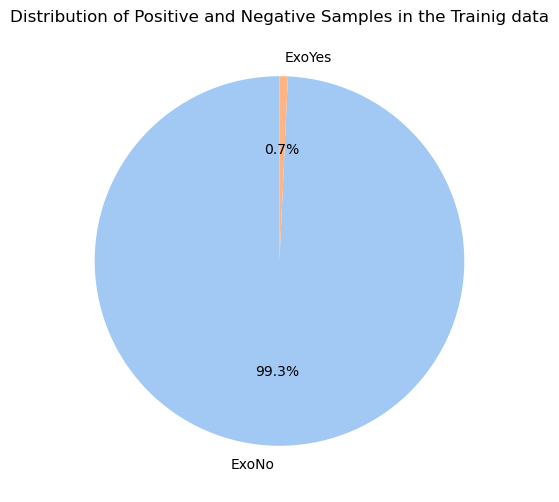

In [51]:
label_count = np.bincount(train_dataset.labels)
label_names = ["ExoNo", "ExoYes"]

plt.figure(figsize=(8,6))
plt.pie(label_count, labels=label_names, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Positive and Negative Samples in the Trainig data')
plt.show()

In [48]:
#step 2: Synthetic Minority OverSampling Technique
smote  =SMOTE(sampling_strategy='all')
# train_dataset.features, train_dataset.labels = smote.fit_resample(train_dataset.features,train_dataset.labels)

print("Class distribution in the training dataset after SMOTE:", pd.Series(train_dataset.labels).value_counts())
print("Class distribution in the testing dataset after SMOTE:", pd.Series(test_dataset.labels).value_counts())

Class distribution in the training dataset after SMOTE: 1    5050
0    5050
Name: count, dtype: int64
Class distribution in the testing dataset after SMOTE: 0    565
1      5
Name: count, dtype: int64


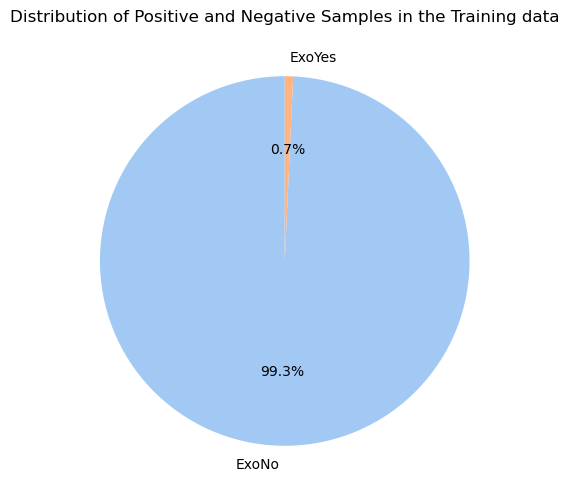

In [52]:
label_count = np.bincount(train_dataset.labels)
label_names = ["ExoNo", "ExoYes"]

plt.figure(figsize=(8,6))
plt.pie(label_count, labels=label_names, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Positive and Negative Samples in the Training data')
plt.show()

## 1.4 Create the DataLoader
We will create a dataloader to help batch and shuffle the data during training and testing. In the initialization of the dataloader, the parameters include: the dataset to be loaded, the batch size, a shuffle argument to determine whether or not to shuffle the dataset after each epoch, and a drop_last parameter that decides whether or not a potential final "incomplete" batch is dropped.

In [10]:
batch_size = 64
spike_grad = surrogate.fast_sigmoid(slope=25)
beta = 0.5
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=False, drop_last=True)

In [17]:
fig = make_subplots(rows=2, cols=2, subplot_titles=("Star #0 (Exoplanet)", "Star #1 (Exoplanet)",
                                                   "Star #3000 (No-Exoplanet)", "Star #3001 (No-Exoplanet)"))

fig.add_trace(
    go.Scatter(y=train_dataset.__getitem__(0)['feature']),
    row=1, col=1)
fig.add_trace(
    go.Scatter(y=train_dataset.__getitem__(1)['feature']),
    row=1, col=2)
fig.add_trace(
    go.Scatter(y=train_dataset.__getitem__(3000)['feature']),
    row=2, col=1)
fig.add_trace(
    go.Scatter(y=train_dataset.__getitem__(3001)['feature']),
    row=2, col=2)

for i in range(1,5):
    fig.update_xaxes(title_text='Time', row=(i-1)//2+1, col=(i-1)%2+1)
    fig.update_yaxes(title_text='Flux', row=(i-1)//2+1, col=(i-1)%2+1)
    
fig.update_layout(height=600, width=800, title_text="ExoYes FLux vs ExoNo Flux", showlegend=True)
fig.show()

In [53]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(3197,128) 
        self.lif1 = snn.Leaky(beta=beta, spike_grad= spike_grad)
        self.fc2 = nn.Linear(64,64)
        self.lif2 = snn.Leaky(beta=beta, spike_grad= spike_grad)
        self.fc3 = nn.Linear(32,2)
        self.lif3 = snn.Leaky(beta=beta, spike_grad= spike_grad)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        cur1 = F.max_pool1d(self.fc1(x), 2)
        spk1, mem1 = self.lif1(cur1, mem1)
        
        cur2 = F.max_pool1d(self.fc2(spk1), 2)
        spk2, mem2 = self.lif2(cur2, mem2)
        
        cur3 = self.fc3(spk2.view(batch_size, -1))
        
        return cur3
    
model = Net()

In [67]:
class WeightedBCEWithRecall(nn.Module):
    def __init__(self, recall_weight=1.5):
        super().__init__()
        self.recall_weight= recall_weight
        self.bce = nn.BCELoss(reduction='none')
        
    def forward(self, outputs, targets):
        bce_loss= self.bce(outputs, targets)
        
        weights = torch.where((targets == 1) & (outputs < 0.5), self.recall_weight, 1.0)
        weighted_loss = bce_loss*weights
        
        return weighted_loss.mean()

In [72]:
#Define Loss Funtion and optimizer
pos_weight= torch.tensor([2.0])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [73]:
results = pd.DataFrame(columns=['Epoch', 'Accuracy', 'Sensitivity', 'Specificity','AUC-ROC', 'Test Loss'])

In [74]:
num_epochs = 200

In [75]:
for epoch in range(num_epochs):
    model.train()
    for data in train_dataloader:
        inputs, labels = data['feature'].float(), data['label']
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        correct = 0
        total = 0
        all_labels = []
        all_predicted= []
        all_probs = []
        for data in test_dataloader:
            inputs, labels = data['feature'].float(), data['label']
            outputs = model(inputs)
            test_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_predicted.extend(predicted.cpu().numpy())


            softmax = torch.nn.Softmax(dim=1)
            probabilities = softmax(outputs)[:, 1]  # Assuming 1 represents the positive class
            all_probs.extend(probabilities.cpu().numpy())
        # output the accuracy (even though it is not very useful in this case)
        accuracy = 100 * correct / total
        # calculate teat loss
        # test_loss =
        # initialize a confusing matrix
        cm = confusion_matrix(all_labels, all_predicted)
        # grab the amount of true negatives and positives, and false negatives and positives.
        tn, fp, fn, tp = cm.ravel()
        # calculate sensitivity
        sensitivity = 100 * tp / (tp + fn) if (tp + fn) > 0 else 0.0
        # calculate specificity
        specificity = 100 * tn / (tn + fp) if (tn + fp) > 0 else 0.0
        # calculate AUC-ROC
        auc_roc = 100 * roc_auc_score(all_labels, all_probs)
        print(
            f'Epoch [{epoch + 1}/{num_epochs}] Test Loss: {test_loss / len(test_dataloader):.2f} '
            f'Test Accuracy: {accuracy:.2f}% Sensitivity: {sensitivity:.2f}% Specificity: {specificity:.2f}% AUC-ROC: {auc_roc:.4f}%'
        )

        results = results._append({
            'Epoch': epoch + 1,
            'Accuracy': accuracy,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'Test Loss': test_loss / len(test_dataloader),
            'AUC-ROC': auc_roc
        }, ignore_index=True)

ValueError: Target size (torch.Size([64])) must be the same as input size (torch.Size([64, 2]))

# Visualize Results

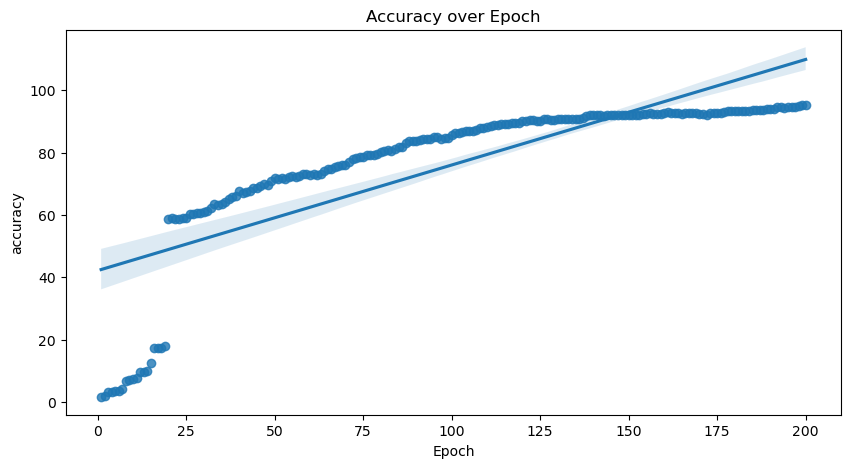

In [58]:
# Plot accuracy
plt.figure(figsize=(10,5))
sns.regplot(x="Epoch", y="Accuracy", data=results, marker ='o')
plt.title("Accuracy over Epoch")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.show()

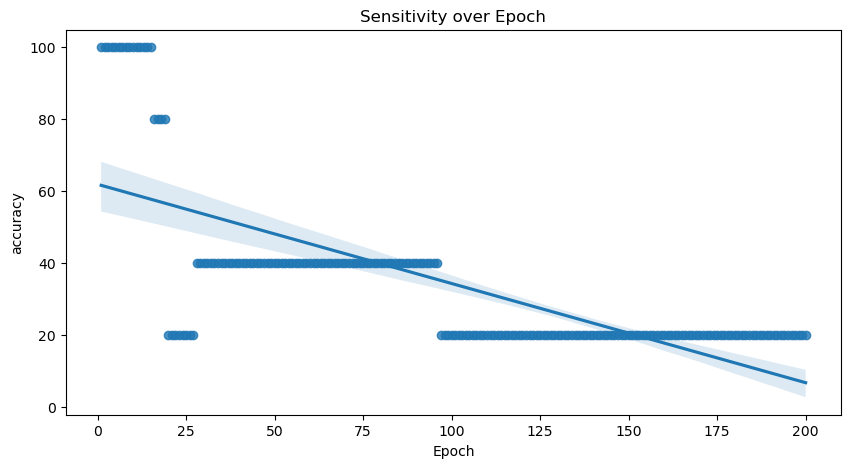

In [60]:
# Plot accuracy
plt.figure(figsize=(10,5))
sns.regplot(x="Epoch", y="Sensitivity", data=results, marker ='o')
plt.title("Sensitivity over Epoch")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.show()

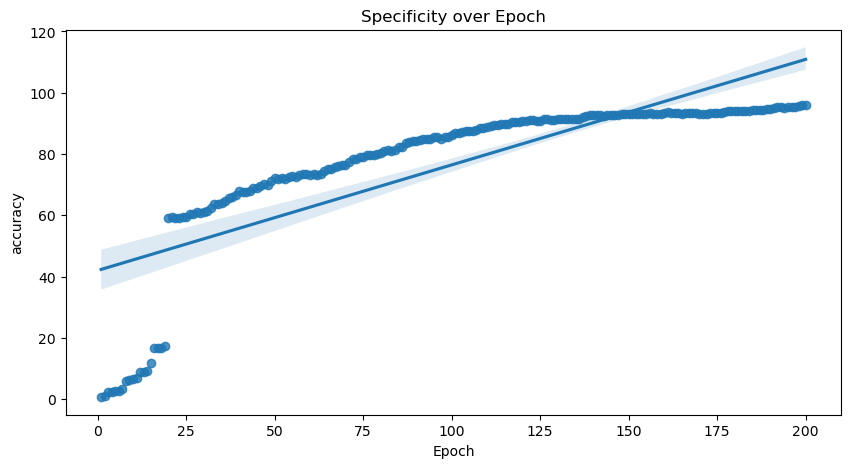

In [61]:
# Plot accuracy
plt.figure(figsize=(10,5))
sns.regplot(x="Epoch", y="Specificity", data=results, marker ='o')
plt.title("Specificity over Epoch")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.show()

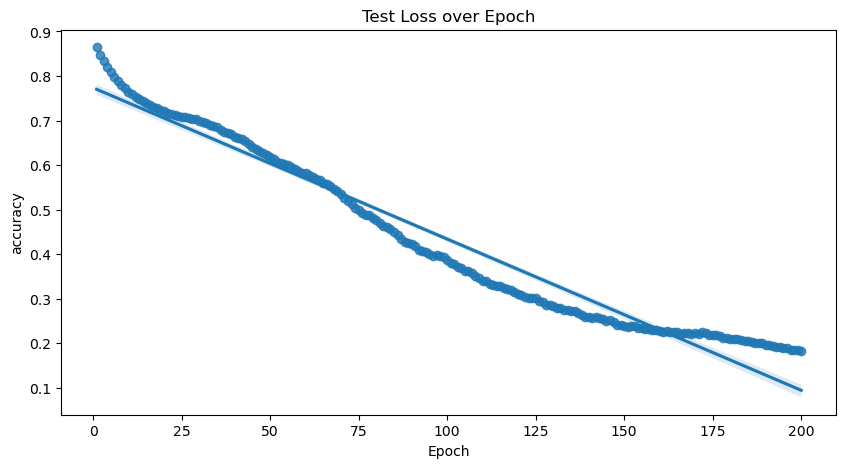

In [62]:
# Plot accuracy
plt.figure(figsize=(10,5))
sns.regplot(x="Epoch", y="Test Loss", data=results, marker ='o')
plt.title("Test Loss over Epoch")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.show()

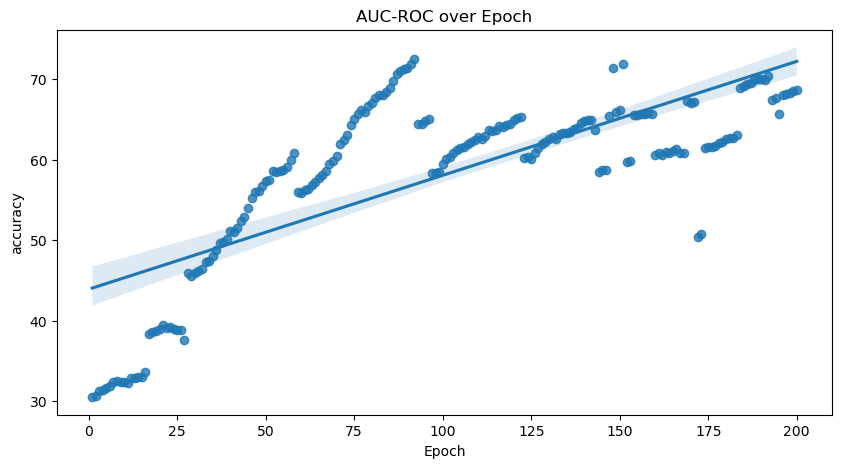

In [63]:
# Plot accuracy
plt.figure(figsize=(10,5))
sns.regplot(x="Epoch", y="AUC-ROC", data=results, marker ='o')
plt.title("AUC-ROC over Epoch")
plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.show()

In [47]:
#@title ## 3.5 Print all together
fig = make_subplots(rows=2, cols=3, subplot_titles=("Sensitivity", "Accuracy", "AUC-ROC", "Specificity", "Test Loss"))

# Sensitivity plot
fig.add_trace(
    go.Scatter(x=results['Epoch'], y=results['Sensitivity'], mode='markers', marker=dict(symbol='circle', size=8)),
    row=1, col=1
)
# fig.update_xaxes(title_text="Epoch", row=1, col=1)
# fig.update_yaxes(title_text="Sensitivity", row=1, col=1)

# Accuracy plot
fig.add_trace(
    go.Scatter(x=results['Epoch'], y=results['Accuracy'], mode='markers', marker=dict(symbol='circle', size=8)),
    row=1, col=2
)
# fig.update_xaxes(title_text="Epoch", row=1, col=2)
# fig.update_yaxes(title_text="Accuracy", row=1, col=2)

# AUC ROC plot
fig.add_trace(
    go.Scatter(x=results['Epoch'], y=results['AUC-ROC'], mode='markers', marker=dict(symbol='circle', size=8)),
    row=1, col=3
)
# fig.update_xaxes(title_text="Epoch", row=1, col=3)
# fig.update_yaxes(title_text="AUC ROC", row=1, col=3)

# Specificity plot
fig.add_trace(
    go.Scatter(x=results['Epoch'], y=results['Specificity'], mode='markers', marker=dict(symbol='circle', size=8)),
    row=2, col=1
)
# fig.update_xaxes(title_text="Epoch", row=2, col=1)
# fig.update_yaxes(title_text="Specificity", row=2, col=1)

# Test Loss plot
fig.add_trace(
    go.Scatter(x=results['Epoch'], y=results['Test Loss'], mode='markers', marker=dict(symbol='circle', size=8)),
    row=2, col=2
)

# Define different y-axis labels
y_labels = ['True Positive Rate (TPR)', 'Accuracy', 'AUC-ROC', 'True False Rate (TFR)', 'Test Loss']

for i in range(1, 6):
    row_num = (i - 1) // 3 + 1
    col_num = (i - 1) % 3 + 1

    fig.update_xaxes(title_text="Epochs", row=row_num, col=col_num)
    fig.update_yaxes(title_text=y_labels[i-1], row=row_num, col=col_num)

# Update layout
fig.update_layout(
    height=600,
    width=1000,
    title_text="Metrics Over Epochs",
    showlegend=False,
    margin=dict(l=50, r=50, t=80, b=50)
)

# Show the plot
fig.show()

In [66]:
# Example input tensor of shape (batch_size, channels, length)
import torch
fc= nn.Linear(3197, 128)
# tnsr = torch.tensor(train_dataloader[1])
# Apply 1D max pooling with kernel size of 2 and stride of 2
# curr = F.max_pool1d(fc(tnsr), kernel_size=2, stride=2)
print(x['feature'].float() for x in train_dataloader)
print(curr.shape)

<generator object <genexpr> at 0x0000025F0757E5F0>
torch.Size([1, 1598])
